In [14]:
import pandas as pd

df = pd.read_csv('/content/twitter_training.csv')

df.head()

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [15]:
print("Shape of dataset:", df.shape)

print("\nColumn names:")
print(df.columns)

print("\nDataset information:")
df.info()

Shape of dataset: (74681, 4)

Column names:
Index(['2401', 'Borderlands', 'Positive',
       'im getting on borderlands and i will murder you all ,'],
      dtype='object')

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74681 entries, 0 to 74680
Data columns (total 4 columns):
 #   Column                                                 Non-Null Count  Dtype 
---  ------                                                 --------------  ----- 
 0   2401                                                   74681 non-null  int64 
 1   Borderlands                                            74681 non-null  object
 2   Positive                                               74681 non-null  object
 3   im getting on borderlands and i will murder you all ,  73995 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [16]:
import pandas as pd

df = pd.read_csv('/content/twitter_training.csv', header=None)

df.columns = ['Tweet_ID', 'Entity', 'Sentiment', 'Tweet']

df.head()

,Tweet_ID,Entity,Sentiment,Tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [17]:
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

Shape: (74682, 4)

Missing values:
Tweet_ID       0
Entity         0
Sentiment      0
Tweet        686
dtype: int64


In [18]:
# Remove rows where Tweet text is missing
df = df.dropna(subset=['Tweet'])

# Check the result
print("Shape after removing missing tweets:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

Shape after removing missing tweets: (73996, 4)

Missing values:
Tweet_ID     0
Entity       0
Sentiment    0
Tweet        0
dtype: int64


In [19]:
print(df['Sentiment'].value_counts())

Sentiment
Negative      22358
Positive      20655
Neutral       18108
Irrelevant    12875
Name: count, dtype: int64


In [20]:
print(df['Sentiment'].value_counts())

Sentiment
Negative      22358
Positive      20655
Neutral       18108
Irrelevant    12875
Name: count, dtype: int64


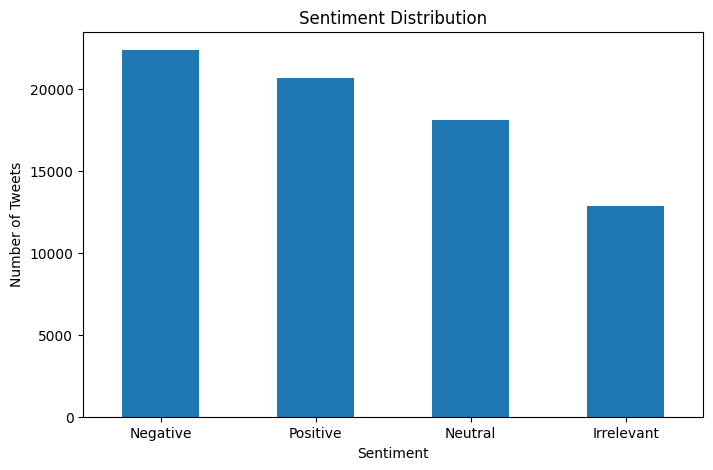

In [21]:
import matplotlib.pyplot as plt

sentiment_counts = df['Sentiment'].value_counts()

plt.figure(figsize=(8, 5))
sentiment_counts.plot(kind='bar')

plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.xticks(rotation=0)

plt.show()

In [22]:
entity_counts = df['Entity'].value_counts()

print("Number of unique entities:", df['Entity'].nunique())
print("\nTop 10 entities:")
print(entity_counts.head(10))

Number of unique entities: 32

Top 10 entities:
Entity
LeagueOfLegends         2377
MaddenNFL               2377
CallOfDuty              2376
Verizon                 2365
TomClancysRainbowSix    2364
Facebook                2362
Microsoft               2361
Dota2                   2359
WorldOfCraft            2357
ApexLegends             2353
Name: count, dtype: int64


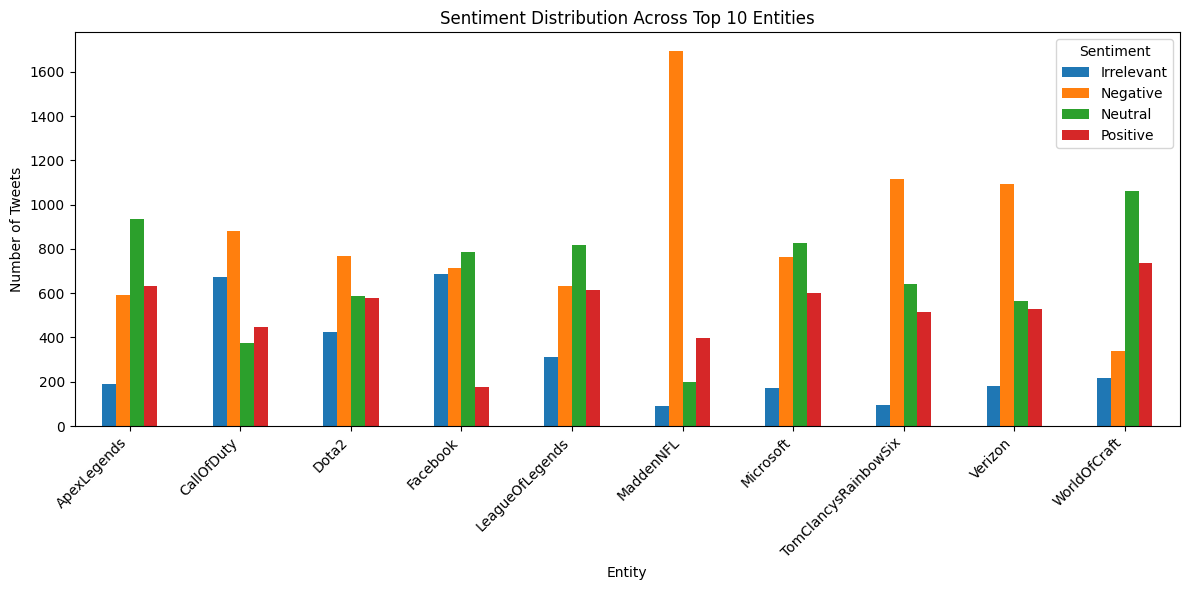

In [23]:
import matplotlib.pyplot as plt

top_entities = df['Entity'].value_counts().head(10).index

entity_sentiment = pd.crosstab(
    df[df['Entity'].isin(top_entities)]['Entity'],
    df[df['Entity'].isin(top_entities)]['Sentiment']
)

entity_sentiment.plot(kind='bar', figsize=(12, 6))

plt.title('Sentiment Distribution Across Top 10 Entities')
plt.xlabel('Entity')
plt.ylabel('Number of Tweets')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

In [24]:
sentiment_percentage = df['Sentiment'].value_counts(normalize=True) * 100

print("Sentiment Percentage:")
print(sentiment_percentage.round(2))

Sentiment Percentage:
Sentiment
Negative      30.22
Positive      27.91
Neutral       24.47
Irrelevant    17.40
Name: proportion, dtype: float64


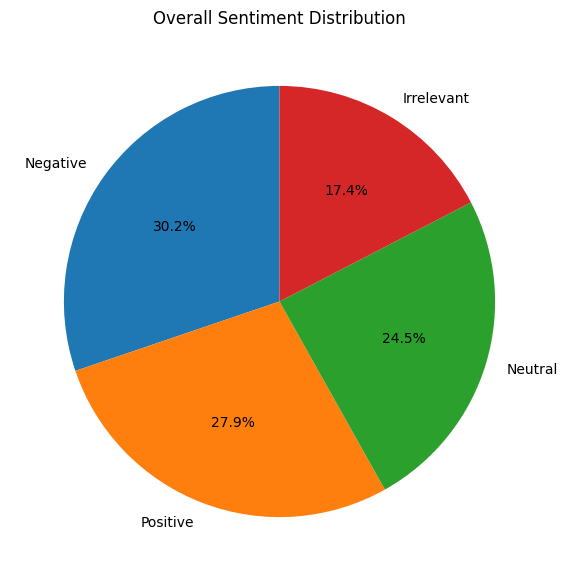

In [25]:
plt.figure(figsize=(7, 7))

df['Sentiment'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Overall Sentiment Distribution')
plt.ylabel('')
plt.show()

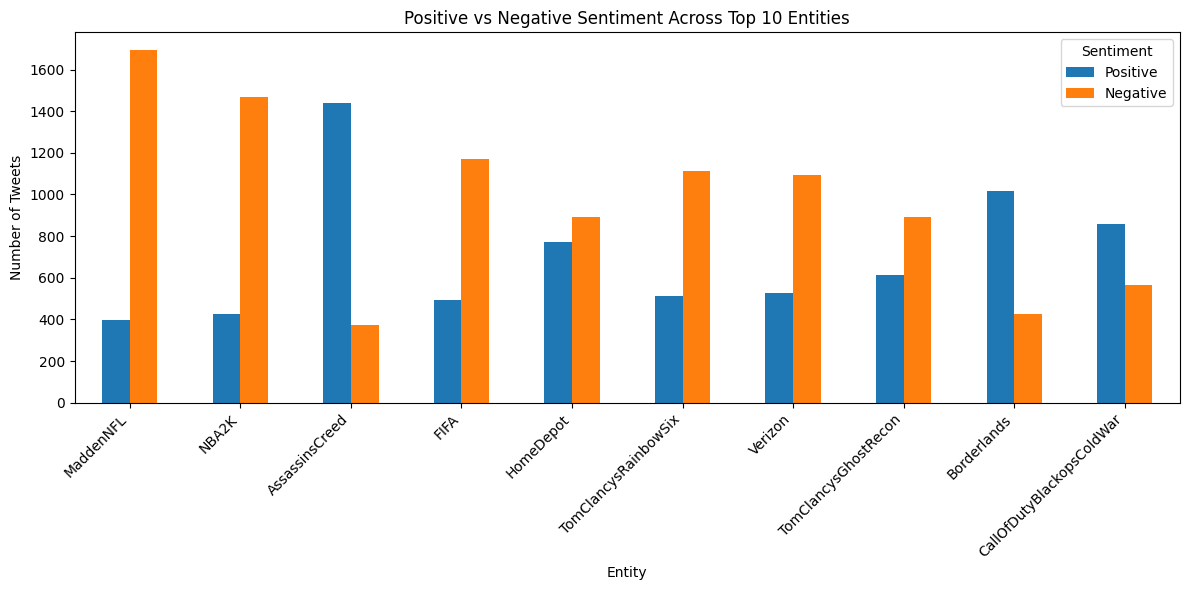

In [26]:
sentiment_by_entity = pd.crosstab(
    df['Entity'],
    df['Sentiment']
)

# Positive and Negative columns only
positive_negative = sentiment_by_entity[['Positive', 'Negative']]

# Top 10 entities by total Positive + Negative tweets
top_10 = positive_negative.sum(axis=1).nlargest(10)

positive_negative_top10 = positive_negative.loc[top_10.index]

positive_negative_top10.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Positive vs Negative Sentiment Across Top 10 Entities')
plt.xlabel('Entity')
plt.ylabel('Number of Tweets')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

## Key Observations

- Negative sentiment represents the largest share of tweets in the dataset.
- Positive sentiment is also highly represented, followed by Neutral sentiment.
- Irrelevant tweets form the smallest sentiment category.
- Sentiment distribution varies across different entities/topics.
- Entity-wise analysis helps identify differences in public sentiment toward different topics.
- The visualizations provide a clear overview of overall and entity-level sentiment patterns.

## Conclusion

This analysis examined sentiment patterns in social media data using the Twitter Entity Sentiment Analysis dataset. The data was cleaned by handling missing tweet values, and sentiment categories were analyzed using counts, percentages, and visualizations. Overall sentiment distribution and entity-wise comparisons were used to understand how sentiment varies across different topics. These findings demonstrate how sentiment analysis can be used to summarize and visualize public attitudes expressed in social media data.